# Инжиниринг категориальных признаков

## Цель работы

Ознакомиться с основными приемами работы с категориальными атрибутами в датасетах для машинного обучения.

## 1. Загрузка данных

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Загрузим датасет Customer Support (результат интеграции данных):

In [11]:
CS_data = pd.read_csv("https://raw.githubusercontent.com/koroteevmv/ML_course/main/ML5.3%20categorical%20features/data/Customer_support_data.csv")
CS_data.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


Основная информация о датасете:

In [12]:
CS_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  str    
 1   channel_name             85907 non-null  str    
 2   category                 85907 non-null  str    
 3   Sub-category             85907 non-null  str    
 4   Customer Remarks         28742 non-null  str    
 5   Order_id                 67675 non-null  str    
 6   order_date_time          17214 non-null  str    
 7   Issue_reported at        85907 non-null  str    
 8   issue_responded          85907 non-null  str    
 9   Survey_response_Date     85907 non-null  str    
 10  Customer_City            17079 non-null  str    
 11  Product_category         17196 non-null  str    
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name               85907 no

Статистика по всем колонкам (включая категориальные):

In [13]:
CS_data.describe(include='all')

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
count,85907,85907,85907,85907,28742,67675,17214,85907,85907,85907,17079,17196,17206.000000,242.000000,85907,85907,85907,85907,85907,85907.000000
unique,85907,3,12,57,18231,67675,13766,30923,30262,31,1782,9,NaN,NaN,1371,40,6,5,5,NaN
top,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Inbound,Returns,Reverse Pickup Enquiry,Good,c27c9bb4-fa36-4140-9f1f-21009254ffdb,09/08/2023 11:55,13/08/2023 10:40,28/08/2023 00:00,28-Aug-23,HYDERABAD,Electronics,NaN,NaN,Wendy Taylor,Carter Park,John Smith,>90,Morning,NaN
freq,1,68142,44097,22389,1390,1,7,13,3378,3452,722,4706,NaN,NaN,429,4273,25261,30660,41426,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5660.774846,462.400826,NaN,NaN,NaN,NaN,NaN,4.242157
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12825.728411,246.295037,NaN,NaN,NaN,NaN,NaN,1.378903
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,1.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,392.000000,293.000000,NaN,NaN,NaN,NaN,NaN,4.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,979.000000,427.000000,NaN,NaN,NaN,NaN,NaN,5.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2699.750000,592.250000,NaN,NaN,NaN,NaN,NaN,5.000000


Загрузим также датасет Титаник:

In [14]:
T_data = pd.read_csv("https://raw.githubusercontent.com/koroteevmv/ML_course/main/ML5.3%20categorical%20features/data/titanic.csv")
T_data.head()

,Unnamed: 0,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,1,0,third,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,2,1,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,2,3,1,third,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,3,4,1,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,4,5,0,third,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Статистика по категориальным атрибутам Титаника:

In [15]:
T_data.describe(exclude=[np.number])

,Pclass,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,891,204,889
unique,3,891,2,681,147,3
top,third,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,491,1,577,7,4,644


## 2. Визуализация распределения категориальных атрибутов

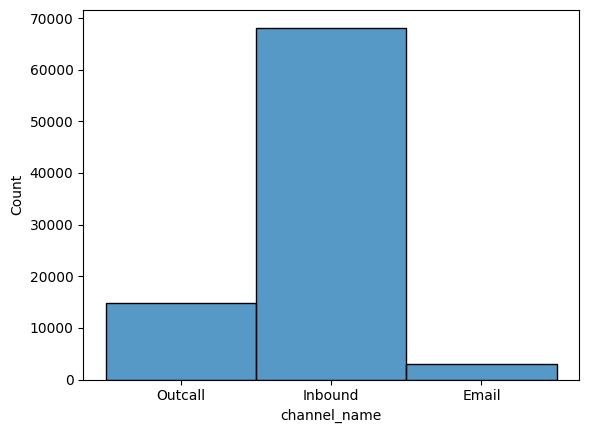

In [16]:
sns.histplot(data=CS_data, x='channel_name')
plt.show()

Количество объектов по каждому каналу:

In [17]:
CS_data.channel_name.value_counts()

channel_name
Inbound    68142
Outcall    14742
Email       3023
Name: count, dtype: int64

Совместное распределение канала и целевой переменной:

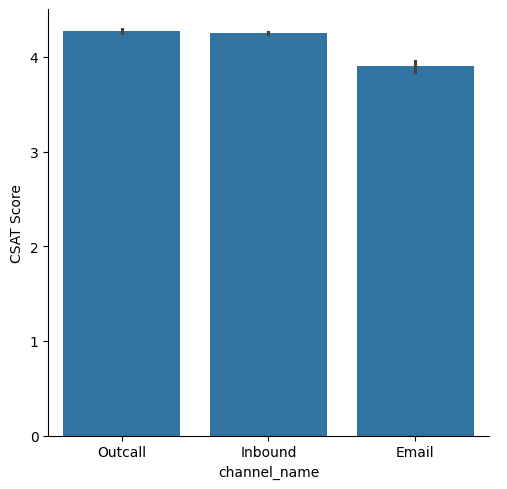

In [18]:
sns.catplot(data=CS_data, x='channel_name', y='CSAT Score', kind='bar')
plt.show()

Распределение по категориям обращений:

In [19]:
CS_data.category.value_counts()

category
Returns               44097
Order Related         23215
Refund Related         4550
Product Queries        3692
Shopzilla Related      2792
Payments related       2327
Feedback               2294
Cancellation           2212
Offers & Cashback       480
Others                   99
App/website              84
Onboarding related       65
Name: count, dtype: int64

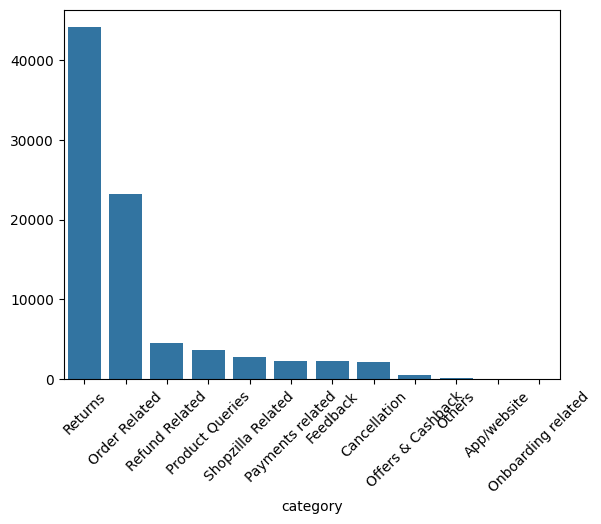

In [20]:
counts = CS_data.category.value_counts()
sns.barplot(x=counts.index, y=counts.values)
plt.xticks(rotation=45)
plt.show()

Распределение по подкатегориям:

In [21]:
CS_data['Sub-category'].value_counts().head(10)

Sub-category
Reverse Pickup Enquiry          22389
Return request                   8523
Delayed                          7388
Order status enquiry             6922
Installation/demo                4116
Fraudulent User                  4108
Product Specific Information     3589
Refund Enquiry                   2665
Wrong                            2597
Missing                          2556
Name: count, dtype: int64

Распределение по городам:

In [22]:
CS_data.Customer_City.value_counts().head(20)

Customer_City
HYDERABAD      722
NEW DELHI      688
PUNE           435
MUMBAI         406
BANGALORE      352
CHENNAI        271
KOLKATA        270
LUCKNOW        254
AHMEDABAD      253
JAIPUR         243
GURGAON        215
PATNA          199
SURAT          175
ALLAHABAD      161
KANPUR         138
VARANASI       137
THANE          129
GHAZIABAD      120
BHUBANESWAR    117
VADODARA       105
Name: count, dtype: int64

## 3. Укрупнение категорий

Бинаризуем Customer Remarks — наличие/отсутствие отзыва:

In [23]:
CS_data['Customer Remarks New'] = (CS_data['Customer Remarks'].str.len() > 3).astype(int)
CS_data['Customer Remarks New']

0        0
1        0
2        0
3        0
4        0
        ..
85902    0
85903    1
85904    1
85905    0
85906    0
Name: Customer Remarks New, Length: 85907, dtype: int64

Бинаризуем наличие заказа:

In [24]:
CS_data['Is_order'] = (~CS_data['Order_id'].isna()).astype(int)
CS_data['Is_order']

0        1
1        1
2        1
3        1
4        1
        ..
85902    1
85903    1
85904    1
85905    1
85906    1
Name: Is_order, Length: 85907, dtype: int64

Укрупним редкие подкатегории, объединив их в 'Other':

In [25]:
CS_data.loc[~CS_data['Sub-category'].isin([
    'Reverse Pickup Enquiry', 'Return request', 'Delayed', 'Order status enquiry', 
    'Installation/demo', 'Fraudulent User', 'Product Specific Information'
    ]), 'Sub-category'] = 'Other'
CS_data['Sub-category'].value_counts()

Sub-category
Other                           28872
Reverse Pickup Enquiry          22389
Return request                   8523
Delayed                          7388
Order status enquiry             6922
Installation/demo                4116
Fraudulent User                  4108
Product Specific Information     3589
Name: count, dtype: int64

## 4. Добавление агрегированной информации

Добавим колонку с количеством обращений у каждого оператора:

In [26]:
CS_data['Agent_count'] = CS_data.groupby(['Agent_name'])['Agent_name'].transform('count')
CS_data[['Agent_name', 'Agent_count']].head()

,Agent_name,Agent_count
0,Richard Buchanan,42
1,Vicki Collins,32
2,Duane Norman,35
3,Patrick Flores,48
4,Christopher Sanchez,124


Добавим колонку с количеством уникальных агентов у каждого руководителя:

In [27]:
CS_data['Sups_no_agents'] = CS_data.groupby(['Supervisor'])['Agent_name'].transform('nunique')
CS_data[['Supervisor', 'Sups_no_agents']].head()

,Supervisor,Sups_no_agents
0,Mason Gupta,41
1,Dylan Kim,17
2,Jackson Park,46
3,Olivia Wang,28
4,Austin Johnson,29


## 5. Заполнение отсутствующих значений

In [28]:
CS_data['Product_category'] = CS_data['Product_category'].fillna('unknown')
CS_data['connected_handling_time'] = CS_data['connected_handling_time'].fillna('0')

## 6. Преобразование категориальных признаков (датасет Титаник)

### Преобразование бинарных атрибутов (LabelEncoder для Sex):

In [29]:
from sklearn.preprocessing import LabelEncoder
LE_sex = LabelEncoder()
T_data.Sex = LE_sex.fit_transform(T_data.Sex)
T_data.head()

,Unnamed: 0,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,1,0,third,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,2,1,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,C
2,2,3,1,third,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,3,4,1,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,S
4,4,5,0,third,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,S


### Преобразование порядковых атрибутов (Pclass):

In [30]:
T_data.Pclass.replace({'first': 1, 'second': 2, 'third': 3}, inplace=True)
T_data.head()

C:\Users\w1nore\AppData\Local\Temp\ipykernel_18348\328739308.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  T_data.Pclass.replace({'first': 1, 'second': 2, 'third': 3}, inplace=True)


,Unnamed: 0,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,1,0,third,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,2,1,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,C
2,2,3,1,third,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,3,4,1,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,S
4,4,5,0,third,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,S


### Преобразование номинальных атрибутов (OneHotEncoder для Embarked):

In [31]:
from sklearn.preprocessing import OneHotEncoder
OH_embarked = OneHotEncoder(sparse_output=False)
dummies = pd.DataFrame(OH_embarked.fit_transform(T_data[['Embarked']]),
                       columns=OH_embarked.get_feature_names_out(['Embarked']), 
                       index=T_data.index)
dummies.head()

,Embarked_C,Embarked_Q,Embarked_S,Embarked_nan
0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0
3,0.0,0.0,1.0,0.0
4,0.0,0.0,1.0,0.0


Объединяем с исходным датафреймом:

In [32]:
T_dummies = pd.concat([T_data, dummies], axis=1).drop(['Embarked'], axis=1)
T_dummies.head()

,Unnamed: 0,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_C,Embarked_Q,Embarked_S,Embarked_nan
0,0,1,0,third,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,0.0,0.0,1.0,0.0
1,1,2,1,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,1.0,0.0,0.0,0.0
2,2,3,1,third,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,0.0,0.0,1.0,0.0
3,3,4,1,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,0.0,0.0,1.0,0.0
4,4,5,0,third,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,0.0,0.0,1.0,0.0


## 7. Удаление лишних столбцов и массовое преобразование (get_dummies)

In [33]:
CS_dropped = CS_data.drop([
    'Unique id', 'Sub-category', 'Customer Remarks', 'Customer_City', 
    'Agent_name', 'Supervisor', 'Order_id', 'order_date_time',
    'Issue_reported at', 'issue_responded', 'Survey_response_Date', 'Item_price'
], axis=1)

Проверяем оставшиеся колонки:

In [34]:
CS_dropped.info()

<class 'pandas.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   channel_name             85907 non-null  str   
 1   category                 85907 non-null  str   
 2   Product_category         85907 non-null  str   
 3   connected_handling_time  85907 non-null  object
 4   Manager                  85907 non-null  str   
 5   Tenure Bucket            85907 non-null  str   
 6   Agent Shift              85907 non-null  str   
 7   CSAT Score               85907 non-null  int64 
 8   Customer Remarks New     85907 non-null  int64 
 9   Is_order                 85907 non-null  int64 
 10  Agent_count              85907 non-null  int64 
 11  Sups_no_agents           85907 non-null  int64 
dtypes: int64(5), object(1), str(6)
memory usage: 7.9+ MB


Массовое преобразование через get_dummies:

In [35]:
CS_dummies = pd.get_dummies(CS_dropped)
CS_dummies.shape

(85907, 258)

In [36]:
CS_dummies.head()

,CSAT Score,Customer Remarks New,Is_order,Agent_count,Sups_no_agents,channel_name_Email,channel_name_Inbound,channel_name_Outcall,category_App/website,category_Cancellation,...,Tenure Bucket_0-30,Tenure Bucket_31-60,Tenure Bucket_61-90,Tenure Bucket_>90,Tenure Bucket_On Job Training,Agent Shift_Afternoon,Agent Shift_Evening,Agent Shift_Morning,Agent Shift_Night,Agent Shift_Split
0,5,0,1,42,41,False,False,True,False,False,...,False,False,False,False,True,False,False,True,False,False
1,5,0,1,32,17,False,False,True,False,False,...,False,False,False,True,False,False,False,True,False,False
2,5,0,1,35,46,False,True,False,False,False,...,False,False,False,False,True,False,True,False,False,False
3,5,0,1,48,28,False,True,False,False,False,...,False,False,False,True,False,False,True,False,False,False
4,5,0,1,124,29,False,True,False,False,True,...,True,False,False,False,False,False,False,True,False,False
